In [1]:
import os
import gc
import zarr
import yaml
import json
import numba
import numpy as np
import polars as pl
import pandas as pd
from tqdm import tqdm
import statsmodels.api as sm

from plotnine import *
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from anngeno import AnnGeno
# pl.Config.set_tbl_rows(15)

/home/dnanexus/anngeno/anngeno/anngeno.py:14: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)


In [2]:
# Configuration and paths
or_threshold_pheno = 0.99
or_threshold_anno = 0.98

eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'

maf=1e-3
n = !wc -l $eur_samples_path
n_eur = int(n[0].split(' ')[0])
mac = maf*(2*n_eur)

config_path = "/home/dnanexus/ukbgym/config_wgs.yaml"
with open(config_path) as f:
    config = yaml.safe_load(f)

# Read the variant consequence configuration
records = []
for group, consequences in config["variant_consequences"].items():
    for consequence in consequences:
        records.append({'variant_class': group, 'vep_consequence': consequence})
var_cons = pl.DataFrame(records)


# Use a list comprehension to flatten the nested dictionary into records
records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records)
all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()

anno_config_df

category,annotation,color,label,annotation_dir
str,str,str,str,i64
"""plof""","""loftee_hc""","""#1f77b4""","""LOFTEE HC""",1
"""missense""","""am_pathogenicity""","""#feb72d""","""AlphaMissense""",1
"""missense""","""esmscoremissense""","""#feb72d""","""ESM1v""",-1
"""genetic_diversity""","""cadd_raw""","""#1f77b4""","""CADD Raw""",1
"""conservation""","""gpn_star_llr_calibrated_mean""","""#942c80""","""GPN-Star""",-1
…,…,…,…,…
"""splicing""","""absplice_dna_max""","""#28a745""","""AbSplice (max)""",1
"""splicing""","""absplice2_max""","""#28a745""","""AbSplice2 (max)""",1
"""regulatory_nondir""","""promoterai_abs""","""#00A99D""","""PromoterAI abs""",1


In [3]:
anno = pl.scan_parquet("/home/dnanexus/data_dir/genebass394genes_olink371genes_variants_union_annotated_250928.parquet")

existing_annos = [c for c in all_annotation_list if c in anno.collect_schema().names()]

# existing_annos = ['cadd_raw', 'gpn_score', 'gpn_star_llr_calibrated_mean']

# Filter variant classes
variant_class = "non_coding"
consequences_for_group = var_cons.filter(
    pl.col('variant_class') == variant_class
)['vep_consequence'].to_list()
filter_expression = pl.any_horizontal(
    (pl.col(c) == 1) for c in consequences_for_group if c in anno.collect_schema().names()
)

min_range = -500
# max_range = +0

anno = (
    anno
    .filter(
        filter_expression &
        # (
        #     (pl.col('consequence_splice_donor_variant') == 0) &
        #     (pl.col('consequence_splice_acceptor_variant') == 0) &
        #     (pl.col('consequence_splice_region_variant') == 0) &
        #     (pl.col('consequence_splice_donor_5th_base_variant') == 0) &
        #     (pl.col('consequence_splice_donor_region_variant') == 0) &
        #     (pl.col('consequence_splice_polypyrimidine_tract_variant') == 0)
        # ) &
        (
            (pl.col('consequence_splice_donor_variant') == 0) &
            (pl.col('consequence_splice_acceptor_variant') == 0)
            # (pl.col('consequence_start_retained_variant') == 0) &
            # (pl.col('consequence_start_lost') == 0)
        ) &
        
        # Distance to TSS range
        (pl.col('dist_to_tss') >= min_range) &

        # Only SNPs
        (pl.col('ref').str.len_chars()==1) & (pl.col('alt').str.len_chars()==1)
    )
    .select(
        set(['id', 'region', 'TSS', 'Strand', 'gene_length', 'gene_name', 'dist_to_tss']).union(set(existing_annos))
    )
    .collect(engine='streaming')
    # .drop_nulls()
)

anno

dist_to_tss,loftee_hc,pangolin_score,absplice_dna_max,verphylop,esmscoremissense,promoterai_abs,TSS,cadd_raw,gene_name,abexp_min,gpn_star_llr_calibrated_mean,promoterai,delta_score,Strand,region,mamphylop,gpn_score,gene_length,absplice2_max,id,am_pathogenicity
i64,i8,f32,f32,f32,f32,f32,i64,f32,str,f64,f64,f32,f32,cat,str,f32,f32,i64,f32,str,f32
165367,0,0.0,0.001,0.217,0.0,0.0,169362534,0.466688,"""LRP2""",-0.006063,0.153293,0.0,0.0,"""-""","""ENSG00000081479""",0.774,-1.5,235427,0.000033,"""chr2:169197167:T:G""",0.0
158242,0,0.0,0.003,0.291,0.0,0.0,169362534,0.104863,"""LRP2""",-0.026342,1.684965,0.0,0.01,"""-""","""ENSG00000081479""",0.085,-0.63,235427,0.000116,"""chr2:169204292:A:T""",0.0
793,0,0.0,0.001,0.023,0.0,0.0,169031324,0.326902,"""ABCB11""",-0.005501,-1.212965,0.0,0.0,"""-""","""ENSG00000073734""",0.015,-1.64,115828,0.000033,"""chr2:169030531:C:T""",0.0
24150,0,0.0,0.001,0.193,0.0,0.0,169031324,-0.070862,"""ABCB11""",-0.005501,-0.238119,0.0,0.0,"""-""","""ENSG00000073734""",0.19,0.08,115828,0.000033,"""chr2:169007174:C:T""",0.0
186782,0,0.0,0.001,0.117,0.0,0.0,169362534,0.211538,"""LRP2""",-0.006358,-1.768037,0.0,0.0,"""-""","""ENSG00000081479""",0.117,-0.98,235427,0.000033,"""chr2:169175752:G:A""",0.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
35231,0,0.0,0.0,0.347,0.0,0.0,112332346,0.113579,"""CD200""",null,0.091713,0.0,0.0,"""+""","""ENSG00000091972""",0.358,-0.53,30467,0.0,"""chr3:112367577:G:A""",0.0
35376,0,0.0,0.0,0.71,0.0,0.0,112332346,0.266626,"""CD200""",null,0.180122,0.0,0.0,"""+""","""ENSG00000091972""",0.733,-1.2,30467,0.0,"""chr3:112367722:G:A""",0.0
34292,0,0.0,0.0,1.253,0.0,0.0,112332346,1.705364,"""CD200""",null,-3.007491,0.0,0.0,"""+""","""ENSG00000091972""",1.363,-4.06,30467,0.0,"""chr3:112366638:G:A""",0.0


In [4]:
melted_anno = (
    anno.unpivot(
        index=["id", "region"],
        on=existing_annos,
        variable_name="annotation",
        value_name="annotation_score"
    )
    .with_columns(
        pl.col("annotation_score").cast(pl.Float32),
        pl.col("region").cast(pl.Utf8),
    )

    # Merge with annotation configuration to get direction and filter
    .join(
        anno_config_df,
        on="annotation",
        how="left"
    )
    .with_columns(
        annotation_score_dircor = pl.col('annotation_score') * pl.col("annotation_dir")
    )
    
    # Implement filtering based on the defined percentile
    .with_columns(
        annotation_score_dircor_rank = pl.col('annotation_score_dircor').rank(method="average").over(["region", "annotation"]),
        anno_score_count = pl.len().over(["region", "annotation"])
    )
    .with_columns(
        annotation_score_dircor_ptile = pl.col('annotation_score_dircor_rank') / pl.col('anno_score_count')
    )
    # .filter( 
    #     pl.col('annotation_score_dircor_ptile') > or_threshold_anno
    # )

    # Filter based on category
    .filter(
        pl.col('category').is_in(['genetic_diversity', 'splicing', 'conservation'])
    )
)

melted_anno

id,region,annotation,annotation_score,category,color,label,annotation_dir,annotation_score_dircor,annotation_score_dircor_rank,anno_score_count,annotation_score_dircor_ptile
str,str,str,f32,str,str,str,i64,f64,f64,u64,f64
"""chr2:169197167:T:G""","""ENSG00000081479""","""cadd_raw""",0.466688,"""genetic_diversity""","""#1f77b4""","""CADD Raw""",1,0.466688,55389.0,78815,0.702772
"""chr2:169204292:A:T""","""ENSG00000081479""","""cadd_raw""",0.104863,"""genetic_diversity""","""#1f77b4""","""CADD Raw""",1,0.104863,26715.0,78815,0.338958
"""chr2:169030531:C:T""","""ENSG00000073734""","""cadd_raw""",0.326902,"""genetic_diversity""","""#1f77b4""","""CADD Raw""",1,0.326902,22368.0,38112,0.586902
"""chr2:169007174:C:T""","""ENSG00000073734""","""cadd_raw""",-0.070862,"""genetic_diversity""","""#1f77b4""","""CADD Raw""",1,-0.070862,6994.0,38112,0.183512
"""chr2:169175752:G:A""","""ENSG00000081479""","""cadd_raw""",0.211538,"""genetic_diversity""","""#1f77b4""","""CADD Raw""",1,0.211538,35851.0,78815,0.454875
…,…,…,…,…,…,…,…,…,…,…,…
"""chr3:112367577:G:A""","""ENSG00000091972""","""absplice2_max""",0.0,"""splicing""","""#28a745""","""AbSplice2 (max)""",1,0.0,939.0,12311,0.076273
"""chr3:112367722:G:A""","""ENSG00000091972""","""absplice2_max""",0.0,"""splicing""","""#28a745""","""AbSplice2 (max)""",1,0.0,939.0,12311,0.076273
"""chr3:112366638:G:A""","""ENSG00000091972""","""absplice2_max""",0.0,"""splicing""","""#28a745""","""AbSplice2 (max)""",1,0.0,939.0,12311,0.076273


In [5]:
ctdf = melted_anno.select(['id', 'region']).unique()['region'].value_counts()
ctdf

region,count
str,u64
"""ENSG00000118762""",23637
"""ENSG00000198670""",42784
"""ENSG00000162551""",24170
"""ENSG00000257727""",2308
"""ENSG00000005471""",25218
…,…
"""ENSG00000140092""",26698
"""ENSG00000133742""",17401
"""ENSG00000154734""",2756


In [6]:
ctdf['count'].describe()

statistic,value
str,f64
"""count""",649.0
"""null_count""",0.0
"""mean""",30431.151002
"""std""",50932.567475
"""min""",373.0
"""25%""",5421.0
"""50%""",14273.0
"""75%""",37613.0
"""max""",546513.0


In [7]:
appv = pl.scan_parquet("/home/dnanexus/data_dir/appv_files/avg_pheno_per_var_quantitative_EUR_genebass1e6_PRScorr_with_percentiles.parquet")

# Create a lazy frame with the unique keys
anno_keys = anno.select(pl.col('id').unique()).lazy()

# Chain the filter and the much faster semi join
appv = (
    appv
        .join(
        anno_keys, on='id', how='semi'
    )
    .filter(
        pl.col('n_individuals') <= mac
    )
    .select(
        ['id', 'phenotype', 'mean_pheno_value_ptile', 'n_individuals']
    )
)

# unique_phenotypes = appv.select('phenotype').unique().collect(engine='streaming').to_series()

In [8]:
# Get gene trait associations

plof = pl.read_parquet('/home/dnanexus/data_dir/association_files/rvat_EUR_500k_regenie.parquet').with_columns(
    phenotype = (pl.col('trait') + '_int'),
    region = pl.col('gene_id'),
    rvat_pval = (10** -pl.col("neg_log10p")),
).filter(
    (pl.col('trait_type') == 'quantitative')
)

loftee_corr = pl.read_parquet("/home/dnanexus/data_dir/association_files/loftee_correlation_quantitative_wgs_EUR_genebass1e6_maf1e3_snp_consistent.parquet")

gene_trait_df = loftee_corr.join(plof[['region', 'phenotype', 'beta', 'rvat_pval']], on=['region', 'phenotype'], how='inner').filter(
    pl.col('loftee_corr')*pl.col('beta') > 0
).with_columns(
    corr_dir = pl.col('loftee_corr')/pl.col('loftee_corr').abs()
)

# gene_trait_df = gene_trait_df.head()
# gene_trait_df = gene_trait_df.filter(
#     pl.col('gene_name') == "LDLR",
#     pl.col('phenotype') == "ldl_direct_int",
# )
gene_trait_df

region,gene_name,phenotype,loftee_corr,n_variants,beta,rvat_pval,corr_dir
str,str,str,f64,u64,f64,f64,f64
"""ENSG00000116183""","""PAPPA2""","""arm_fatfree_mass_right_int""",-0.014747,82603,-0.195409,9.1637e-8,-1.0
"""ENSG00000129083""","""COPB1""","""arm_fatfree_mass_right_int""",-0.014338,13594,-0.397279,0.006626,-1.0
"""ENSG00000100578""","""KIAA0586""","""arm_fatfree_mass_right_int""",-0.010787,28541,-0.058463,0.000305,-1.0
"""ENSG00000157766""","""ACAN""","""arm_fatfree_mass_right_int""",-0.036259,20244,-0.436618,6.0395e-11,-1.0
"""ENSG00000140443""","""IGF1R""","""arm_fatfree_mass_right_int""",-0.013644,82469,-0.412619,2.8609e-8,-1.0
…,…,…,…,…,…,…,…
"""ENSG00000112077""","""RHAG""","""reticulocyte_count_int""",0.033239,9849,0.952411,1.8038e-41,1.0
"""ENSG00000029534""","""ANK1""","""reticulocyte_count_int""",0.02685,54620,0.656849,2.1682e-10,1.0
"""ENSG00000197969""","""VPS13A""","""reticulocyte_count_int""",0.003971,55477,0.176348,2.1188e-7,1.0


## Debug

In [7]:
gene_trait_df = gene_trait_df.filter(
    pl.col('gene_name') == "LDLR",
    pl.col('phenotype') == "ldl_direct_int",
)
gene_trait_df

region,gene_name,phenotype,loftee_corr,n_variants,beta,rvat_pval,corr_dir
str,str,str,f64,u64,f64,f64,f64
"""ENSG00000130164""","""LDLR""","""ldl_direct_int""",0.037908,12461,0.707871,4.1162e-11,1.0


In [8]:
# --- 1. Lazily prepare the filter keys ---
region_keys = gene_trait_df.lazy().select(pl.col('region').unique())
anno_ids_lazy = melted_anno.lazy().join(
    region_keys, on='region', how='semi'
).select(pl.col('id').unique())


# --- Build main query (same as before, but stop before group_by) ---
gp_ptile = (
    appv
    .join(anno_ids_lazy, on="id", how="semi")
    .join(
        melted_anno.lazy().drop([c for c in melted_anno.columns if 'is_nan' in c]), 
        on="id", 
        how="inner"
    )
    .join(
        gene_trait_df.lazy(), 
        on=["region", "phenotype"], 
        how="inner"
    )
    .with_columns(
        mean_pheno_value_dircor_ptile = pl.when(pl.col('corr_dir') == -1)
            .then(1 - pl.col('mean_pheno_value_ptile'))
            .otherwise(pl.col('mean_pheno_value_ptile')),
    )
)

# Create a lazy dataframe of cutoffs
cutoffs_lazy = pl.LazyFrame({
    # scale from or_threshold_anno to 1.0
    "ptile_cutoff": [or_threshold_anno + (i/100)*(1-or_threshold_anno) for i in range(100)]
})

# Cross join with cutoffs and compute odds ratios
or_ptile = (
    gp_ptile
    .select(["annotation", "region", "gene_name", "phenotype", "annotation_score_dircor_ptile", "mean_pheno_value_dircor_ptile"])
    .join(cutoffs_lazy, how="cross")
    .with_columns(
        above_cutoff = pl.col("annotation_score_dircor_ptile") >= pl.col("ptile_cutoff")
    )
    .group_by(["annotation", "region", "gene_name", "phenotype", "ptile_cutoff"])
    .agg(
        n_dis_above_cutoff = (
            (pl.col("annotation_score_dircor_ptile") >= pl.col("ptile_cutoff")) & 
            (pl.col("mean_pheno_value_dircor_ptile") >= or_threshold_pheno)
        ).sum(),
        n_notdis_above_cutoff = (
            (pl.col("annotation_score_dircor_ptile") >= pl.col("ptile_cutoff")) & 
            (pl.col("mean_pheno_value_dircor_ptile") < or_threshold_pheno)
        ).sum(),
        n_dis_below_cutoff = (
            (pl.col("annotation_score_dircor_ptile") < pl.col("ptile_cutoff")) & 
            (pl.col("mean_pheno_value_dircor_ptile") >= or_threshold_pheno)
        ).sum(),
        n_notdis_below_cutoff = (
            (pl.col("annotation_score_dircor_ptile") < pl.col("ptile_cutoff")) & 
            (pl.col("mean_pheno_value_dircor_ptile") < or_threshold_pheno)
        ).sum()
    )
    .with_columns(
        odds_ratio = (pl.col("n_dis_above_cutoff") / pl.col("n_notdis_above_cutoff")) / (pl.col("n_dis_below_cutoff") / pl.col("n_notdis_below_cutoff"))
    )
    .collect(engine='streaming')
)

or_ptile

annotation,region,gene_name,phenotype,ptile_cutoff,n_dis_above_cutoff,n_notdis_above_cutoff,n_dis_below_cutoff,n_notdis_below_cutoff,odds_ratio
str,str,str,str,f64,u64,u64,u64,u64,f64
"""verphylop""","""ENSG00000130164""","""LDLR""","""ldl_direct_int""",0.95,26,407,408,7803,1.221744
"""delta_score""","""ENSG00000130164""","""LDLR""","""ldl_direct_int""",0.9505,23,384,411,7826,1.140498
"""cadd_raw""","""ENSG00000130164""","""LDLR""","""ldl_direct_int""",0.952,26,373,408,7837,1.338919
"""pangolin_score""","""ENSG00000130164""","""LDLR""","""ldl_direct_int""",0.954,19,319,415,7891,1.132523
"""gpn_star_llr_calibrated_mean""","""ENSG00000130164""","""LDLR""","""ldl_direct_int""",0.9565,22,334,412,7876,1.259171
…,…,…,…,…,…,…,…,…,…
"""absplice2_max""","""ENSG00000130164""","""LDLR""","""ldl_direct_int""",0.9965,3,25,431,8185,2.278886
"""mamphylop""","""ENSG00000130164""","""LDLR""","""ldl_direct_int""",0.998,0,21,434,8189,0.0
"""mamphylop""","""ENSG00000130164""","""LDLR""","""ldl_direct_int""",0.999,0,9,434,8201,0.0


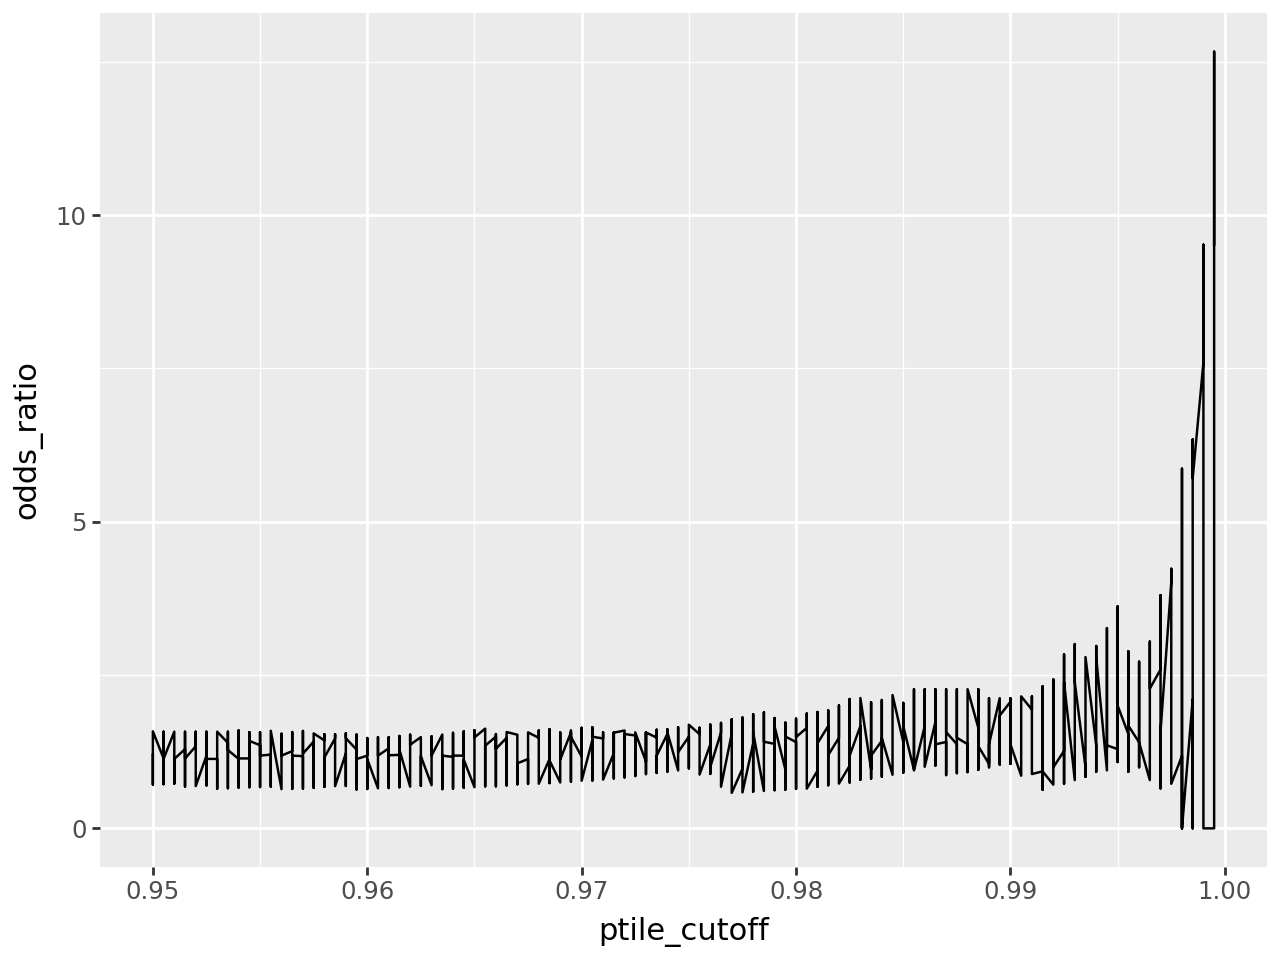

In [9]:
(
    ggplot(
        or_ptile,
        aes(x='ptile_cutoff', y='odds_ratio')
    )
    + geom_line()
)

## Resume code

In [9]:
# --- 1. Lazily prepare the filter keys ---
region_keys = gene_trait_df.lazy().select(pl.col('region').unique())
anno_ids_lazy = melted_anno.lazy().join(
    region_keys, on='region', how='semi'
).select(pl.col('id').unique())


# --- Build main query (same as before, but stop before group_by) ---
gp_lazy = (
    appv
    .join(anno_ids_lazy, on="id", how="semi")
    .join(
        melted_anno.lazy().drop([c for c in melted_anno.columns if 'is_nan' in c]), 
        on="id", 
        how="inner"
    )
    .join(
        gene_trait_df.lazy(), 
        on=["region", "phenotype"], 
        how="inner"
    )
    .with_columns(
        mean_pheno_value_dircor_ptile = pl.when(pl.col('corr_dir') == -1)
            .then(1 - pl.col('mean_pheno_value_ptile'))
            .otherwise(pl.col('mean_pheno_value_ptile')),
    )
)

n_steps = 100
# Create a lazy dataframe of cutoffs
cutoffs_lazy = pl.LazyFrame({
    # scale from or_threshold_anno to 1.0
    # "ptile_cutoff": [or_threshold_anno + (i/100)*(1-or_threshold_anno) for i in range(100)]
    "ptile_cutoff": [or_threshold_anno + (i/n_steps)*(1-or_threshold_anno) for i in range(n_steps)]
})

# Cross join with cutoffs and compute odds ratios
or_lazy = (
    gp_lazy
    .select(["annotation", "region", "gene_name", "phenotype", "annotation_score_dircor_ptile", "mean_pheno_value_dircor_ptile"])
    .join(cutoffs_lazy, how="cross")
    .with_columns(
        above_cutoff = pl.col("annotation_score_dircor_ptile") >= pl.col("ptile_cutoff")
    )
    .group_by(["annotation", "region", "gene_name", "phenotype", "ptile_cutoff"])
    .agg(
        n_dis_above_cutoff = (
            (pl.col("annotation_score_dircor_ptile") >= pl.col("ptile_cutoff")) & 
            (pl.col("mean_pheno_value_dircor_ptile") >= or_threshold_pheno)
        ).sum(),
        n_notdis_above_cutoff = (
            (pl.col("annotation_score_dircor_ptile") >= pl.col("ptile_cutoff")) & 
            (pl.col("mean_pheno_value_dircor_ptile") < or_threshold_pheno)
        ).sum(),
        n_dis_below_cutoff = (
            (pl.col("annotation_score_dircor_ptile") < pl.col("ptile_cutoff")) & 
            (pl.col("mean_pheno_value_dircor_ptile") >= or_threshold_pheno)
        ).sum(),
        n_notdis_below_cutoff = (
            (pl.col("annotation_score_dircor_ptile") < pl.col("ptile_cutoff")) & 
            (pl.col("mean_pheno_value_dircor_ptile") < or_threshold_pheno)
        ).sum()
    )
    .with_columns(
        # odds_ratio = ((pl.col("n_dis_above_cutoff") + 1) / (pl.col("n_notdis_above_cutoff")+1)) / (1 - or_threshold_pheno)
        odds_ratio = (pl.col("n_dis_above_cutoff") / pl.col("n_notdis_above_cutoff")) / (pl.col("n_dis_below_cutoff") / pl.col("n_notdis_below_cutoff"))
    )
)

# Execute
print("Executing with odds ratios...")
or_df = or_lazy.collect(engine='streaming').sort('ptile_cutoff')

# or_df.write_parquet('/home/dnanexus/data_dir/odds_ratio_deep_intronic_wgs_EUR_genebass1e6_maf1e3.parquet')
or_df.write_parquet('/home/dnanexus/data_dir/odds_ratio_non_coding_0.99_wgs_EUR_genebass1e6_maf1e3.parquet')
# or_df.write_parquet('/home/dnanexus/data_dir/odds_ratio_utr_0.99_wgs_EUR_genebass1e6_maf1e3.parquet')
or_df

Executing with odds ratios...


: 

In [ ]:
# or_df.write_parquet('/home/dnanexus/data_dir/odds_ratio_non_coding_0.99_wgs_EUR_genebass1e6_maf1e3.parquet')
# or_df = pl.read_parquet('/home/dnanexus/data_dir/odds_ratio_deep_intronic_wgs_EUR_genebass1e6_maf1e3.parquet')
or_df

annotation,region,gene_name,phenotype,ptile_cutoff,n_dis_above_cutoff,n_notdis_above_cutoff,n_dis_below_cutoff,n_notdis_below_cutoff,odds_ratio
str,str,str,str,f64,u64,u64,u64,u64,f64
"""cadd_raw""","""ENSG00000119403""","""PHF19""","""arm_predicted_mass_left_int""",0.95,3,178,47,3599,1.290581
"""cadd_raw""","""ENSG00000145386""","""CCNA2""","""arm_predicted_mass_right_int""",0.95,0,114,26,2126,0.0
"""gpn_score""","""ENSG00000171714""","""ANO5""","""aspartate_aminotransferase_int""",0.95,1,252,61,4671,0.303864
"""delta_score""","""ENSG00000080345""","""RIF1""","""body_mass_index_bmi_int""",0.95,1,31,71,5726,2.601545
"""cadd_raw""","""ENSG00000169174""","""PCSK9""","""cholesterol_int""",0.95,3,121,39,2317,1.472982
…,…,…,…,…,…,…,…,…,…
"""pangolin_score""","""ENSG00000100578""","""KIAA0586""","""whole_body_water_mass_int""",0.999,0,5,37,3013,0.0
"""delta_score""","""ENSG00000100578""","""KIAA0586""","""whole_body_water_mass_int""",0.999,0,4,37,3014,0.0
"""cadd_raw""","""ENSG00000140443""","""IGF1R""","""whole_body_water_mass_int""",0.999,0,7,49,5778,0.0


In [ ]:
or_df['ptile_cutoff'].n_unique()

50

In [ ]:
plt_df = (
    or_df
    .drop_nans()
    .filter(pl.col("odds_ratio").is_finite())
    .with_columns(
        n_gene_phenos = pl.len().over(['ptile_cutoff', 'annotation']),
        med_odds_ratio = pl.col('odds_ratio').median().over(['ptile_cutoff', 'annotation']),
        avg_odds_ratio = pl.col('odds_ratio').mean().over(['ptile_cutoff', 'annotation']),
        std_odds_ratio = pl.col('odds_ratio').std().over(['ptile_cutoff', 'annotation']),
    )
    .with_columns(
        std_ci_upper = pl.col('avg_odds_ratio') + 1.96 * (pl.col('std_odds_ratio')),
        std_ci_lower = pl.col('avg_odds_ratio') - 1.96 * (pl.col('std_odds_ratio')),
    )
    .select(['annotation', 'ptile_cutoff', 'n_gene_phenos', 'med_odds_ratio', 'avg_odds_ratio', 'std_odds_ratio', 'std_ci_upper', 'std_ci_lower'])
    .unique()
    .join(
        anno_config_df.select(['annotation', 'color', 'label']),
        on='annotation',
        how='left'
    )
    .sort('ptile_cutoff')
)
plt_df

annotation,ptile_cutoff,n_gene_phenos,med_odds_ratio,avg_odds_ratio,std_odds_ratio,std_ci_upper,std_ci_lower,color,label
str,f64,u64,f64,f64,f64,f64,f64,str,str
"""gpn_star_llr_calibrated_mean""",0.95,1162,1.039536,1.238489,1.056038,3.308323,-0.831344,"""#942c80""","""GPN-Star"""
"""pangolin_score""",0.95,1147,0.734237,1.115361,1.446058,3.949633,-1.718912,"""#28a745""","""Pangolin"""
"""delta_score""",0.95,1088,0.0,1.244696,4.133454,9.346265,-6.856873,"""#28a745""","""SpliceAI"""
"""absplice_dna_max""",0.95,1089,0.862295,1.167396,1.619398,4.341417,-2.006625,"""#28a745""","""AbSplice (max)"""
"""cadd_raw""",0.95,1162,1.011896,1.209707,1.032613,3.233629,-0.814214,"""#1f77b4""","""CADD Raw"""
…,…,…,…,…,…,…,…,…,…
"""verphylop""",0.999,1099,0.0,1.904852,9.01526,19.574761,-15.765058,"""#942c80""","""Vertebrate PhyloP"""
"""mamphylop""",0.999,795,0.0,1.704053,9.316846,19.965071,-16.556965,"""#942c80""","""Mammalian PhyloP"""
"""cadd_raw""",0.999,1144,0.0,1.462944,8.956061,19.016823,-16.090935,"""#1f77b4""","""CADD Raw"""


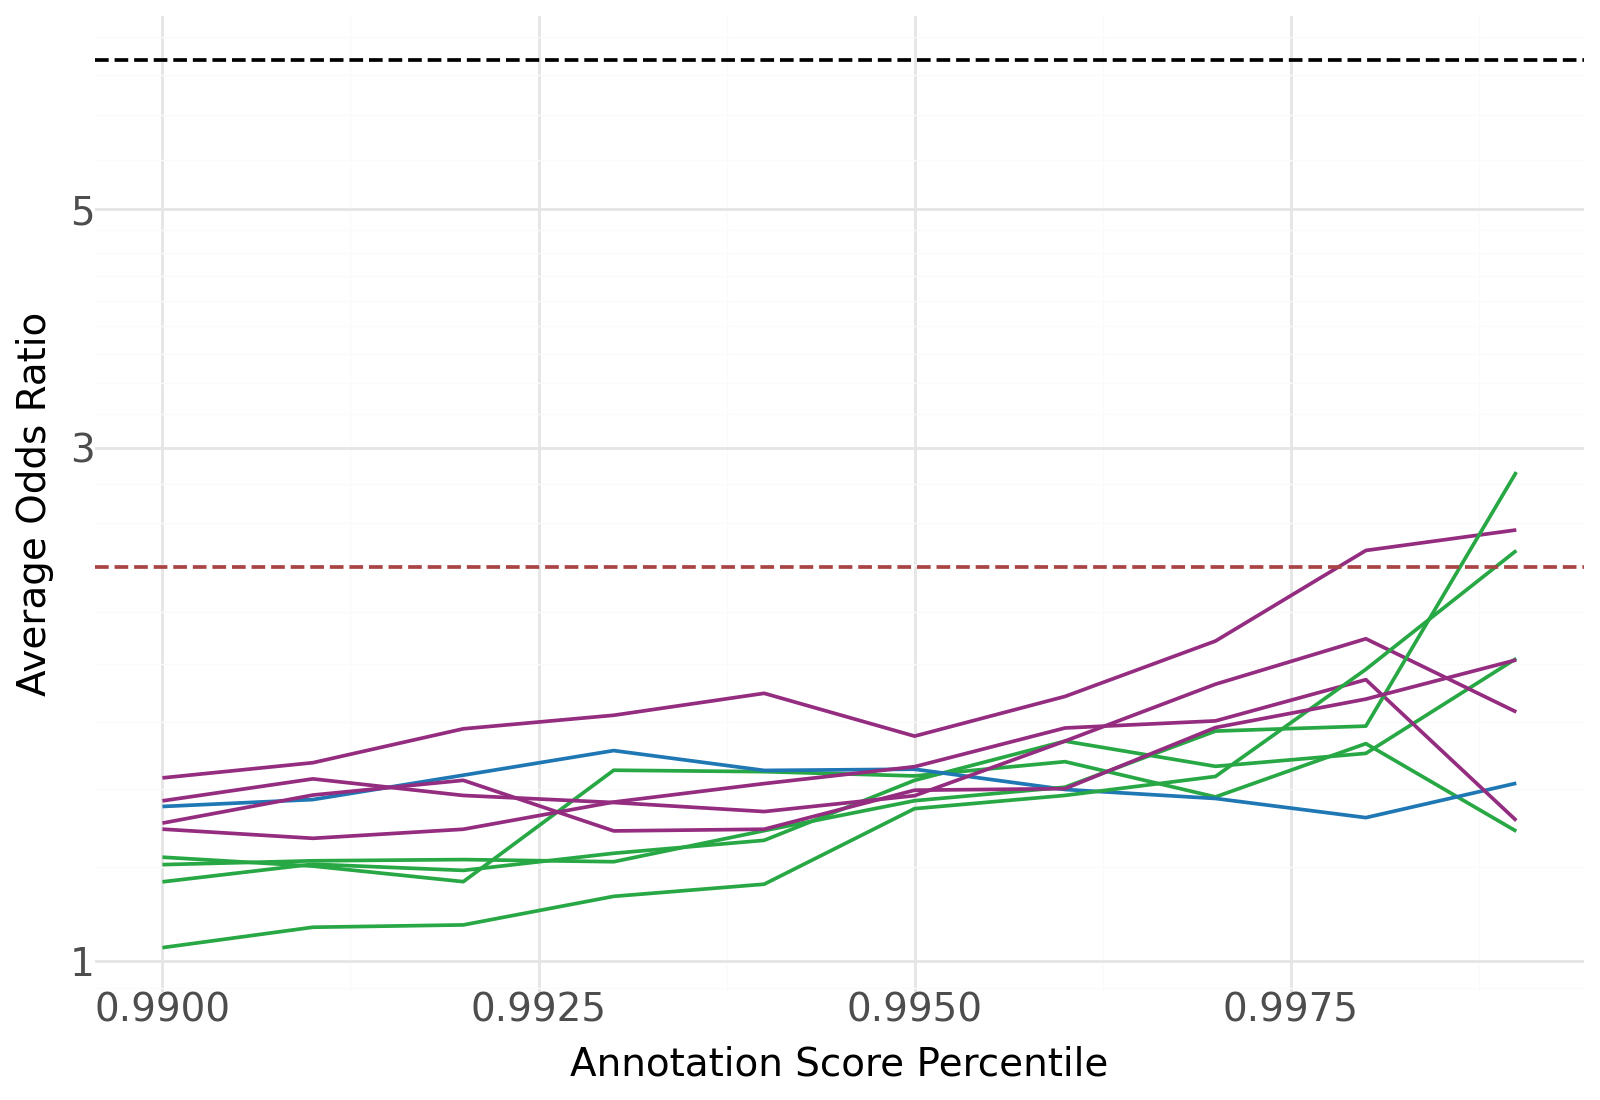

In [ ]:
color_dict = dict(zip(plt_df['label'], plt_df['color']))


am_lof_or_mean = {
    'loftee_all': 9.998645,
    'am_0.8_all': 3.628273,
    'loftee_coding': 6.874422,
    'am_0.8_coding': 2.323273
}

am_lof_or_median = {
    'loftee_all': 3.573782,
    'am_0.8_all': 2.027029,
    'loftee_coding': 3.04127,
    'am_0.8_coding': 1.770242
}

(
    ggplot(
        plt_df.filter(pl.col('ptile_cutoff')>=0.99),
        aes(x='ptile_cutoff', y='avg_odds_ratio', color='label')
        # aes(x='ptile_cutoff', y='med_odds_ratio', color='label')
    )
    + geom_line(size=0.75)
    + geom_hline(aes(yintercept=am_lof_or_mean['loftee_coding']), linetype='dashed', color='black', size=0.75)
    + geom_hline(aes(yintercept=am_lof_or_mean['am_0.8_coding']), linetype='dashed', color='#AA4344', size=0.75)
    # + geom_ribbon(aes(ymin='std_ci_lower', ymax='std_ci_upper', fill='label'), alpha=0.2)
    # + scale_fill_manual(values=color_dict)
    + scale_color_manual(values=color_dict)
    + labs(
        y="Average Odds Ratio",
        x="Annotation Score Percentile",
        color="Annotation",
    )
    + scale_y_log10()
    + theme_minimal()
    + theme(
        figure_size=(8, 5.5),
        legend_position = 'none',
        axis_text=element_text(size=14),
        axis_title=element_text(size=14),
    )
)

In [ ]:
plt_df.sort('avg_odds_ratio', descending=True)

annotation,ptile_cutoff,n_gene_phenos,med_odds_ratio,avg_odds_ratio,std_odds_ratio,std_ci_upper,std_ci_lower,color,label
str,f64,u64,f64,f64,f64,f64,f64,str,str
"""delta_score""",0.999,1074,0.0,2.847614,11.992592,26.353093,-20.657866,"""#28a745""","""SpliceAI"""
"""gpn_score""",0.999,1142,0.0,2.515843,10.501915,23.099597,-18.067911,"""#942c80""","""GPN-MSA"""
"""gpn_score""",0.998,1162,0.0,2.407805,8.146111,18.374181,-13.558572,"""#942c80""","""GPN-MSA"""
"""pangolin_score""",0.999,1144,0.0,2.407138,10.294697,22.584745,-17.770468,"""#28a745""","""Pangolin"""
"""mamphylop""",0.998,932,0.0,1.993043,7.708198,17.101112,-13.115025,"""#942c80""","""Mammalian PhyloP"""
…,…,…,…,…,…,…,…,…,…
"""pangolin_score""",0.987,1147,0.0,1.062364,1.930736,4.846607,-2.721879,"""#28a745""","""Pangolin"""
"""pangolin_score""",0.985,1147,0.0,1.047729,1.805226,4.585973,-2.490514,"""#28a745""","""Pangolin"""
"""pangolin_score""",0.988,1147,0.0,1.038085,1.990401,4.939271,-2.863101,"""#28a745""","""Pangolin"""


In [ ]:
plt_df.filter(pl.col('avg_odds_ratio') >= am_lof_or_mean['loftee_coding']).sort('ptile_cutoff').head()

annotation,ptile_cutoff,n_gene_phenos,med_odds_ratio,avg_odds_ratio,std_odds_ratio,std_ci_upper,std_ci_lower,color,label
str,f64,u64,f64,f64,f64,f64,f64,str,str


In [ ]:
melted_anno.filter(
    (pl.col('annotation') == 'absplice_dna_max') &
    (pl.col('annotation_score_dircor_ptile')>0.9975)
)['id'].n_unique()

6747

In [ ]:
plt_df.filter(pl.col('ptile_cutoff') == 0.9999).sort('avg_odds_ratio', descending=True)

annotation,ptile_cutoff,n_gene_phenos,med_odds_ratio,avg_odds_ratio,std_odds_ratio,std_ci_upper,std_ci_lower,color,label
str,f64,u64,f64,f64,f64,f64,f64,str,str
